# PTH validation — predicted hosts vs Liang unenriched sylph

Host annotations use **genomovar-majority consensus** within each viral species (highest count; alphabetical on ties), keyed by the species representative.

Sylph PTH uses the **cascade** host-match method:

1. Predicted host **species** co-detected in the sample
2. Else **genus singleton**: exactly one bacterial species from the predicted host genus
3. Else **family singleton**: exactly one bacterial species from the predicted host family

For viruses with a resolved host, Liang **unenriched** sylph profiles (`True_cov`) are used to compute:

1. **Percent co-occurrence** = 100 × (virus+host co-detections) / (virus detections)
2. **Spearman ρ** of virus vs host `True_cov` using **only co-detected samples**, and only for viruses with **≥ 3 co-detections**
3. **Raw phage-to-host ratio** per sample from **cascade** PTH
4. **Std of phage-to-host ratio** (`std_pth`)

**True species host** includes every virus with a predicted host species (co-detection not required for inclusion), plus genus/family-only predictions resolved via cascade. Compared to non-host species within the host genus and randomly assigned hosts.

Association / boxplot analyses are limited to viruses detected in **≥ 3 samples**.


In [1]:
from pathlib import Path
import glob
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy.stats import fisher_exact

pl.Config.set_tbl_rows(12)
plt.rcParams.update({'font.size': 14})
random.seed(42)
np.random.seed(42)

FIG4 = Path('../figure_4')
FIG1 = Path('../figure_1')
OUTS = FIG4 / 'activity_profiling/liang_enriched_results/2026-04-03_outputs'
SYLPH_DIR = OUTS / 'referenceanalyze/sylph'
GTDB_META = FIG4 / 'sylph_tax/gtdb_r226_metadata.tsv.gz'
PHIST_HOST = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_phisthost.tsv.gz'
CRISPR_HOST = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_crisprhost.tsv.gz'
SPECIES_INFO = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_info.tsv.gz'
GENOMOVAR_INFO = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_genomovars_info.tsv.gz'

N_CO_OCCURRENCE_THRESHOLD = 1  # min co-detections for control pair inclusion (True species host has no co-detection filter)
N_VIRUS_DETECTION_MIN = 3     # boxplot / association analyses: virus detected in ≥ this many samples
N_SPEARMAN_MIN_CODETECT = 3    # Spearman only for pairs with ≥ this many co-detections
N_PERMUTATIONS = 1000

print('SYLPH_DIR exists:', SYLPH_DIR.is_dir())
print('SPECIES_INFO exists:', SPECIES_INFO.is_file())
print('GENOMOVAR_INFO exists:', GENOMOVAR_INFO.is_file())

SYLPH_DIR exists: True
SPECIES_INFO exists: True
GENOMOVAR_INFO exists: True


## 1. Species-level hosts via genomovar consensus

Per-genomovar PHIST+CRISPR hosts are aggregated within each viral species: take the **most frequent** host label (highest count; alphabetical if tied). Annotations are keyed by the **species representative** (`votu_rep`) so they join to sylph `Contig_name`.

In [2]:
# Per-genomovar PHIST + CRISPR host calls
uhvdb_genomovar_host = (
    pl.read_csv(PHIST_HOST, separator='\t')[
        ['uhvdb_id', 'total_connections', 'rank', 'agreement', 'consensus_taxonomy']
    ]
    .join(
        pl.read_csv(CRISPR_HOST, separator='\t')[
            ['uhvdb_id', 'total_connections', 'rank', 'agreement', 'top_taxonomy']
        ],
        on=['uhvdb_id', 'rank'],
        how='full',
        suffix='_crispr',
    )
    .fill_null(0)
    .with_columns([
        pl.col('consensus_taxonomy').str.replace(r'^(s|g|f)__', ''),
    ])
    .with_columns([
        pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy'))
        .then(pl.col('consensus_taxonomy'))
        .when(
            (pl.col('total_connections') * pl.col('agreement'))
            >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))
        )
        .then(pl.col('consensus_taxonomy'))
        .otherwise(pl.col('top_taxonomy'))
        .alias('final_taxonomy'),
        pl.when(pl.col('rank').is_not_null())
        .then(pl.col('rank'))
        .otherwise(pl.col('rank_crispr'))
        .alias('final_rank'),
        pl.when(pl.col('uhvdb_id').is_not_null())
        .then(pl.col('uhvdb_id'))
        .otherwise(pl.col('uhvdb_id_crispr'))
        .alias('final_id'),
    ])
    .group_by('final_id')
    .agg([
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'species').first().alias('final_species'),
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'genus').first().alias('final_genus'),
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'family').first().alias('final_family'),
    ])
    .rename({'final_id': 'uhvdb_id'})
)

species_info = pl.read_csv(SPECIES_INFO, separator='\t').select([
    'uhvdb_id',
    pl.col('cluster_id').alias('species_cluster_id'),
    pl.col('votu_rep').alias('species_rep'),
])
genomovar_reps = (
    pl.read_csv(GENOMOVAR_INFO, separator='\t')
    .filter(pl.col('uhvdb_id') == pl.col('votu_rep'))
    .select(pl.col('uhvdb_id').alias('genomovar_rep'))
    .unique()
)

# Genomovar reps within each viral species
gv_in_species = (
    species_info
    .join(genomovar_reps, left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
    .join(uhvdb_genomovar_host, on='uhvdb_id', how='left')
    .rename({'uhvdb_id': 'genomovar_rep'})
)


def majority_host(df: pl.DataFrame, col: str) -> pl.DataFrame:
    """Highest-count label per species; alphabetical break on ties."""
    return (
        df
        .filter(pl.col(col).is_not_null())
        .group_by(['species_cluster_id', col])
        .agg(pl.len().alias('n'))
        .sort(['species_cluster_id', 'n', col], descending=[False, True, False])
        .unique('species_cluster_id', maintain_order=True)
        .select(['species_cluster_id', col])
    )


species_consensus = (
    species_info
    .select(['species_cluster_id', 'species_rep'])
    .unique()
    .join(majority_host(gv_in_species, 'final_species'), on='species_cluster_id', how='left')
    .join(majority_host(gv_in_species, 'final_genus'), on='species_cluster_id', how='left')
    .join(majority_host(gv_in_species, 'final_family'), on='species_cluster_id', how='left')
)

# Key by species rep for sylph Contig_name joins
host_preds = species_consensus.select([
    pl.col('species_rep').alias('uhvdb_id'),
    'final_species',
    'final_genus',
    'final_family',
])
species_hosts = host_preds.filter(pl.col('final_species').is_not_null())

# QC vs species-rep-only annotation
rep_only = (
    species_consensus
    .select(['species_rep'])
    .join(uhvdb_genomovar_host, left_on='species_rep', right_on='uhvdb_id', how='left')
    .rename({
        'final_species': 'rep_final_species',
        'final_genus': 'rep_final_genus',
    })
)
qc = species_consensus.join(rep_only, on='species_rep', how='left')
both_sp = qc.filter(pl.col('final_species').is_not_null() & pl.col('rep_final_species').is_not_null())
print('species clusters:', host_preds.height)
print('with consensus host species:', species_hosts.height)
print('with consensus host genus:', host_preds.filter(pl.col('final_genus').is_not_null()).height)
print('with consensus host family:', host_preds.filter(pl.col('final_family').is_not_null()).height)
print(
    'agree with species-rep (species host):',
    int((both_sp['final_species'] == both_sp['rep_final_species']).sum()),
    '/',
    both_sp.height,
    f"({100 * (both_sp['final_species'] == both_sp['rep_final_species']).mean():.2f}%)",
)
host_preds.head()


species clusters: 199442
with consensus host species: 115481
with consensus host genus: 176701
with consensus host family: 180984
agree with species-rep (species host): 112258 / 112668 (99.64%)


uhvdb_id,final_species,final_genus,final_family
str,str,str,str
"""UHVDB-571840""","""Porphyromonas sp900548415""","""Porphyromonas""","""Porphyromonadaceae"""
"""UHVDB-389795""",null,"""Streptococcus""","""Streptococcaceae"""
"""UHVDB-294546""","""Escherichia coli""","""Escherichia""","""Enterobacteriaceae"""
"""UHVDB-264965""","""Faecousia sp900547405""","""Faecousia""","""Oscillospiraceae"""
"""UHVDB-328001""",null,"""Collinsella""","""Coriobacteriaceae"""


## 2. Load unenriched sylph profiles + GTDB taxonomy

In [3]:
gtdb_meta = (
    pl.read_csv(
        GTDB_META,
        separator='\t',
        has_header=False,
        new_columns=['accession', 'lineage'],
    )
    .with_columns([
        pl.col('lineage').str.extract(r'f__([^;]+)', 1).alias('family'),
        pl.col('lineage').str.extract(r'g__([^;]+)', 1).alias('genus'),
        pl.col('lineage').str.extract(r's__([^;]+)', 1).alias('species'),
    ])
    .unique('accession')
)

sylph_lst = []
for path in sorted(glob.glob(str(SYLPH_DIR / 'liang_*_unenriched' / 'liang_*_unenriched.profile.tsv'))):
    sample_id = Path(path).name.replace('.profile.tsv', '')
    if '_enriched' in sample_id and '_unenriched' not in sample_id:
        continue
    df = (
        pl.read_csv(path, separator='\t')
        .with_columns([
            pl.lit(sample_id).alias('sample_id'),
            pl.col('True_cov').cast(pl.Float64),
            pl.col('Genome_file').str.extract(r'(GC[AF]_\d+\.\d+)', 1).alias('accession'),
            pl.when(pl.col('Genome_file').str.contains('uhvdb'))
            .then(pl.lit('phage'))
            .when(pl.col('Genome_file').str.contains('gtdb'))
            .then(pl.lit('bacteria'))
            .otherwise(pl.lit('other'))
            .alias('row_type'),
        ])
    )
    sylph_lst.append(df)

sylph_df = pl.concat(sylph_lst)
N_SAMPLES = sylph_df['sample_id'].n_unique()
print('unenriched samples:', N_SAMPLES, 'rows:', sylph_df.height)
print(sylph_df['row_type'].value_counts())

phage_all = (
    sylph_df
    .filter(pl.col('row_type') == 'phage')
    .select([
        'sample_id',
        pl.col('Contig_name').alias('virus_species'),
        pl.col('True_cov').alias('virus_True_cov'),
    ])
    .join(host_preds, left_on='virus_species', right_on='uhvdb_id', how='left')
)

bac_df = (
    sylph_df
    .filter(pl.col('row_type') == 'bacteria')
    .join(gtdb_meta, on='accession', how='left')
    .filter(pl.col('species').is_not_null())
    .group_by(['sample_id', 'species', 'genus', 'family'])
    .agg(pl.col('True_cov').max().alias('host_True_cov'))
    .rename({'species': 'bac_species'})
)

# ---------------------------------------------------------------------------
# Sample-level cascade PTH (species → genus singleton → family singleton)
# ---------------------------------------------------------------------------
phage_with_host = phage_all.select([
    'sample_id', 'virus_species', 'virus_True_cov',
    'final_species', 'final_genus', 'final_family',
])

species_hits = (
    phage_with_host
    .filter(pl.col('final_species').is_not_null())
    .join(
        bac_df.select(['sample_id', 'bac_species', 'host_True_cov']),
        left_on=['sample_id', 'final_species'],
        right_on=['sample_id', 'bac_species'],
        how='inner',
    )
    .with_columns([
        pl.lit('species_codetected').alias('ratio_rule'),
        pl.col('final_species').alias('matched_host_species'),
    ])
)
matched_keys = species_hits.select(['sample_id', 'virus_species']).unique()

genus_singleton = (
    bac_df
    .filter(pl.col('genus').is_not_null())
    .group_by(['sample_id', 'genus'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('bac_species').first().alias('bac_species'),
        pl.col('host_True_cov').first().alias('host_True_cov'),
    ])
    .filter(pl.col('n_species') == 1)
)
genus_hits = (
    phage_with_host
    .join(matched_keys, on=['sample_id', 'virus_species'], how='anti')
    .filter(pl.col('final_genus').is_not_null())
    .join(
        genus_singleton.select(['sample_id', 'genus', 'bac_species', 'host_True_cov']),
        left_on=['sample_id', 'final_genus'],
        right_on=['sample_id', 'genus'],
        how='inner',
    )
    .with_columns([
        pl.lit('genus_singleton').alias('ratio_rule'),
        pl.col('bac_species').alias('matched_host_species'),
    ])
)
matched_keys = pl.concat([
    matched_keys,
    genus_hits.select(['sample_id', 'virus_species']),
]).unique()

family_singleton = (
    bac_df
    .filter(pl.col('family').is_not_null())
    .group_by(['sample_id', 'family'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('bac_species').first().alias('bac_species'),
        pl.col('host_True_cov').first().alias('host_True_cov'),
    ])
    .filter(pl.col('n_species') == 1)
)
family_hits = (
    phage_with_host
    .join(matched_keys, on=['sample_id', 'virus_species'], how='anti')
    .filter(pl.col('final_family').is_not_null())
    .join(
        family_singleton.select(['sample_id', 'family', 'bac_species', 'host_True_cov']),
        left_on=['sample_id', 'final_family'],
        right_on=['sample_id', 'family'],
        how='inner',
    )
    .with_columns([
        pl.lit('family_singleton').alias('ratio_rule'),
        pl.col('bac_species').alias('matched_host_species'),
    ])
)

ratio_cols = [
    'sample_id', 'virus_species', 'virus_True_cov', 'host_True_cov',
    'final_species', 'final_genus', 'final_family',
    'matched_host_species', 'ratio_rule',
]
cascade_pth_df = (
    pl.concat([
        species_hits.select(ratio_cols),
        genus_hits.select(ratio_cols),
        family_hits.select(ratio_cols),
    ])
    .with_columns(
        (pl.col('virus_True_cov') / pl.col('host_True_cov')).alias('sample_pth')
    )
    .filter(pl.col('host_True_cov') > 0)
    .unique(subset=['sample_id', 'virus_species'], keep='first')
)

print('Cascade PTH rows:', cascade_pth_df.height)
print(cascade_pth_df['ratio_rule'].value_counts())

# ---------------------------------------------------------------------------
# Virus-level association hosts for co-occurrence / controls
# 1) species-level predictions (always included; co-detection not required)
# 2) genus/family-only: majority matched host from cascade samples
# ---------------------------------------------------------------------------
species_mapping = (
    phage_all
    .filter(pl.col('final_species').is_not_null())
    .select([
        'virus_species',
        pl.col('final_species').alias('predicted_host_species'),
    ])
    .unique()
    .with_columns(pl.lit('species').alias('host_source'))
)

species_keys = species_mapping.select('virus_species')
cascade_majority = (
    cascade_pth_df
    .join(species_keys, on='virus_species', how='anti')
    .group_by(['virus_species', 'matched_host_species'])
    .agg(pl.len().alias('n'))
    .sort(['virus_species', 'n', 'matched_host_species'], descending=[False, True, False])
    .unique('virus_species', maintain_order=True)
    .select([
        'virus_species',
        pl.col('matched_host_species').alias('predicted_host_species'),
        pl.lit('cascade').alias('host_source'),
    ])
)

association_mapping = pl.concat([species_mapping, cascade_majority])

virus_df = (
    phage_all
    .join(association_mapping, on='virus_species', how='inner')
    .select([
        'sample_id',
        'virus_species',
        'virus_True_cov',
        'predicted_host_species',
        'final_genus',
        'final_family',
        'host_source',
    ])
)

print('detected virus species:', phage_all['virus_species'].n_unique())
print(association_mapping['host_source'].value_counts())
print(
    'virus detections in association set:',
    virus_df.height,
    'unique viruses:',
    virus_df['virus_species'].n_unique(),
)
print(
    'bacterial species detections:',
    bac_df.height,
    'unique bac species:',
    bac_df['bac_species'].n_unique(),
)
virus_df.head()


unenriched samples: 38 rows: 5267
shape: (2, 2)
┌──────────┬───────┐
│ row_type ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ bacteria ┆ 1586  │
│ phage    ┆ 3681  │
└──────────┴───────┘
Cascade PTH rows: 2596
shape: (3, 2)
┌────────────────────┬───────┐
│ ratio_rule         ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ genus_singleton    ┆ 225   │
│ species_codetected ┆ 2333  │
│ family_singleton   ┆ 38    │
└────────────────────┴───────┘
detected virus species: 2139
shape: (2, 2)
┌─────────────┬───────┐
│ host_source ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ species     ┆ 1692  │
│ cascade     ┆ 115   │
└─────────────┴───────┘
virus detections in association set: 3073 unique viruses: 1807
bacterial species detections: 1586 unique bac species: 481


sample_id,virus_species,virus_True_cov,predicted_host_species,final_genus,final_family,host_source
str,str,f64,str,str,str,str
"""liang_100_unenriched""","""UHVDB-39904""",342.458,"""Ruminococcus_E intestinalis""","""Ruminococcus_E""","""Acutalibacteraceae""","""species"""
"""liang_100_unenriched""","""UHVDB-226544""",108.299,"""Phocaeicola vulgatus""","""Phocaeicola""","""Bacteroidaceae""","""cascade"""
"""liang_100_unenriched""","""UHVDB-403915""",68.784,"""Bacteroides ovatus""","""Bacteroides""","""Bacteroidaceae""","""species"""
"""liang_100_unenriched""","""UHVDB-61270""",52.686,"""Bifidobacterium bifidum""","""Bifidobacterium""","""Bifidobacteriaceae""","""species"""
"""liang_100_unenriched""","""UHVDB-333838""",48.295,"""Bifidobacterium longum""","""Bifidobacterium""","""Bifidobacteriaceae""","""species"""


## 2b. Detected virus species by host-prediction coverage

Counts of unique sylph-detected virus species:
1. All detected
2. With a predicted **host genus**
3. With a predicted **host species**


shape: (3, 2)
┌────────────────────────┬─────────────────┐
│ category               ┆ n_virus_species │
│ ---                    ┆ ---             │
│ str                    ┆ i64             │
╞════════════════════════╪═════════════════╡
│ Detected virus species ┆ 2139            │
│ Predicted host genus   ┆ 1977            │
│ Predicted host species ┆ 1692            │
└────────────────────────┴─────────────────┘


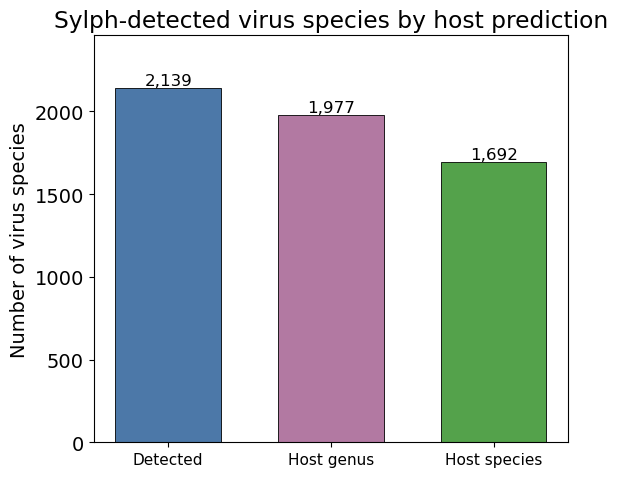

wrote pth_validation_host_coverage_bar.png
wrote pth_validation_host_coverage_counts.tsv


In [4]:
species_pred_viruses = (
    phage_all
    .filter(pl.col('final_species').is_not_null())
    .select('virus_species')
    .unique()
)

genus_pred_viruses = (
    phage_all
    .filter(pl.col('final_genus').is_not_null())
    .select('virus_species')
    .unique()
)

host_coverage_counts = pl.DataFrame({
    'category': [
        'Detected virus species',
        'Predicted host genus',
        'Predicted host species',
    ],
    'n_virus_species': [
        phage_all['virus_species'].n_unique(),
        genus_pred_viruses.height,
        species_pred_viruses.height,
    ],
})

print(host_coverage_counts)

plot_labels = [
    'Detected',
    'Host genus',
    'Host species',
]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    plot_labels,
    host_coverage_counts['n_virus_species'].to_list(),
    color=['#4C78A8', '#B279A2', '#54A24B'],
    edgecolor='black',
    linewidth=0.6,
    width=0.65,
)
ax.set_ylabel('Number of virus species')
ax.set_title('Sylph-detected virus species by host prediction')
ax.set_ylim(0, max(host_coverage_counts['n_virus_species'].to_list()) * 1.15)
ax.tick_params(axis='x', labelsize=11)
for bar, n in zip(bars, host_coverage_counts['n_virus_species'].to_list()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{n:,}',
        ha='center',
        va='bottom',
        fontsize=12,
    )
fig.tight_layout()
fig.savefig('pth_validation_host_coverage_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print('wrote pth_validation_host_coverage_bar.png')
host_coverage_counts.write_csv('pth_validation_host_coverage_counts.tsv', separator='\t')
print('wrote pth_validation_host_coverage_counts.tsv')


## 3. Association metrics (true predicted hosts + controls)

Limited to viruses detected in **≥ `N_VIRUS_DETECTION_MIN` samples**.

Hosts included:
- **species**: consensus `final_species` (co-detection not required for inclusion)
- **cascade**: genus/family-only consensus resolved via the sample-level **cascade** PTH host (majority matched host across samples)

**True species host**: every qualifying virus with a resolved host species. Co-occurrence is vs that host. Raw PTH / Spearman use **cascade** sample PTH when available (`pct_cooccur` can be <100% when the predicted host is missing from some samples).

Compared against:
- **Non-host species within host genus**: other bacterial species in the predicted host genus, excluding the predicted host species (pairs with ≥ `N_CO_OCCURRENCE_THRESHOLD` co-detections)
- **Random bacterial species**: hosts randomly reassigned from the full bacterial pool (pairs with ≥ `N_CO_OCCURRENCE_THRESHOLD` co-detections)

Metrics:
- **Percent co-occurrence** = 100 × (samples with virus+host) / (samples with virus)
- Fisher exact enrichment (one-sided greater)
- **Spearman ρ** / PTH only if ≥ `N_SPEARMAN_MIN_CODETECT` co-detections (co-detected samples only)


In [5]:
BACTERIAL_POOL = bac_df.select('bac_species').unique().to_series().to_list()

v_prev = virus_df.group_by('virus_species').agg(pl.len().alias('v_total_count'))
b_prev = bac_df.group_by('bac_species').agg(pl.len().alias('b_total_count'))

viruses_ge_min = (
    v_prev
    .filter(pl.col('v_total_count') >= N_VIRUS_DETECTION_MIN)
    .select('virus_species')
)

true_mapping = (
    association_mapping
    .select(['virus_species', 'predicted_host_species', 'host_source'])
    .join(viruses_ge_min, on='virus_species', how='inner')
)

print(
    f'viruses with predicted host: {association_mapping.height} → '
    f'detected in ≥{N_VIRUS_DETECTION_MIN} samples: {true_mapping.height}'
)


def get_random_host(true_host: str) -> str:
    choice = random.choice(BACTERIAL_POOL)
    while choice == true_host:
        choice = random.choice(BACTERIAL_POOL)
    return choice


null_mapping_list = []
for i in range(N_PERMUTATIONS):
    null_mapping_list.append(
        true_mapping
        .with_columns([
            pl.col('predicted_host_species')
            .map_elements(get_random_host, return_dtype=pl.String)
            .alias('null_host'),
            pl.lit(f'Null_{i}').alias('iteration'),
        ])
        .select(['virus_species', 'null_host', 'iteration'])
    )
null_mapping_expanded = pl.concat(null_mapping_list)


def fast_fisher(counts):
    odds_ratio, p_value = fisher_exact(
        [[counts[0], counts[1]], [counts[2], counts[3]]],
        alternative='greater',
    )
    return {'odds_ratio': float(odds_ratio), 'p_value': float(p_value)}


def run_association_pipeline(
    v_df,
    b_df,
    mapping_table,
    host_col_name,
    label,
    is_null=False,
    min_n11=N_CO_OCCURRENCE_THRESHOLD,
    include_zero_codetect=False,
):
    group_cols = ['virus_species', host_col_name]
    if is_null:
        group_cols.append('iteration')

    co_occurrences = (
        v_df.select(['sample_id', 'virus_species'])
        .join(mapping_table, on='virus_species')
        .join(
            b_df.select(['sample_id', 'bac_species']),
            left_on=['sample_id', host_col_name],
            right_on=['sample_id', 'bac_species'],
            how='inner',
        )
        .group_by(group_cols)
        .agg(pl.len().alias('n11'))
    )

    if include_zero_codetect:
        # Keep every mapped virus↔host pair, including n11 == 0
        pair_base = (
            mapping_table
            .join(v_prev, on='virus_species', how='inner')
            .join(co_occurrences, on=group_cols, how='left')
            .with_columns(pl.col('n11').fill_null(0))
            .join(b_prev, left_on=host_col_name, right_on='bac_species', how='left')
            .with_columns(pl.col('b_total_count').fill_null(0))
        )
    else:
        pair_base = (
            co_occurrences
            .join(v_prev, on='virus_species')
            .join(b_prev, left_on=host_col_name, right_on='bac_species')
        )

    fisher_table = (
        pair_base
        .with_columns([
            (pl.col('v_total_count') - pl.col('n11')).alias('n10'),
            (pl.col('b_total_count') - pl.col('n11')).alias('n01'),
            (N_SAMPLES - pl.col('v_total_count') - pl.col('b_total_count') + pl.col('n11')).alias('n00'),
            (100.0 * pl.col('n11') / pl.col('v_total_count')).alias('pct_cooccur'),
        ])
    )

    if min_n11 is not None and min_n11 > 0:
        fisher_table = fisher_table.filter(pl.col('n11') >= min_n11)

    stats_base = (
        fisher_table
        .with_columns(
            pl.struct(['n11', 'n10', 'n01', 'n00'])
            .map_elements(
                lambda r: fast_fisher([r['n11'], r['n10'], r['n01'], r['n00']]),
                return_dtype=pl.Struct({'odds_ratio': pl.Float64, 'p_value': pl.Float64}),
            )
            .alias('fisher_stats')
        )
        .unnest('fisher_stats')
    )

    # Spearman / PTH on co-detected samples only
    joint_abundances = (
        v_df.select(['sample_id', 'virus_species', 'virus_True_cov'])
        .join(mapping_table, on='virus_species')
        .join(
            b_df.select(['sample_id', 'bac_species', 'host_True_cov']),
            left_on=['sample_id', host_col_name],
            right_on=['sample_id', 'bac_species'],
            how='inner',
        )
        .join(stats_base.select(group_cols), on=group_cols, how='inner')
        .filter(pl.col('host_True_cov') > 0)
        .with_columns(
            (pl.col('virus_True_cov') / pl.col('host_True_cov')).alias('sample_pth')
        )
    )

    abundance_stats = (
        joint_abundances
        .group_by(group_cols)
        .agg([
            pl.when(pl.len() >= N_SPEARMAN_MIN_CODETECT)
            .then(pl.corr('virus_True_cov', 'host_True_cov', method='spearman'))
            .otherwise(None)
            .alias('spearman_rho'),
            pl.col('sample_pth').mean().alias('mean_pth'),
            pl.col('sample_pth').std().alias('std_pth'),
            pl.col('sample_pth').median().alias('median_pth'),
            pl.col('sample_pth').max().alias('max_pth'),
            pl.len().alias('n_codetect_samples'),
        ])
    )

    final_output = (
        stats_base
        .join(abundance_stats, on=group_cols, how='left')
        .with_columns([
            pl.lit(label).alias('type'),
            pl.col('n_codetect_samples').fill_null(0),
        ])
        .select([
            'virus_species',
            host_col_name,
            'n11',
            'v_total_count',
            'pct_cooccur',
            'odds_ratio',
            'p_value',
            'spearman_rho',
            'mean_pth',
            'std_pth',
            'median_pth',
            'max_pth',
            'n_codetect_samples',
            'type',
        ])
    )
    return final_output.rename({host_col_name: 'host_name'}), joint_abundances


# True species host: qualifying viruses with a resolved host (include n11 == 0);
# co-occurrence vs predicted/majority host; PTH metrics from cascade
true_results, true_pair_abundances = run_association_pipeline(
    virus_df,
    bac_df,
    true_mapping.select(['virus_species', 'predicted_host_species']),
    'predicted_host_species',
    'True species host',
    is_null=False,
    min_n11=0,
    include_zero_codetect=True,
)
true_results = true_results.join(
    association_mapping.select(['virus_species', 'host_source']),
    on='virus_species',
    how='left',
)

# Override true-host sample PTH with cascade values
true_pair_abundances = (
    cascade_pth_df
    .join(true_mapping.select('virus_species'), on='virus_species', how='inner')
    .select([
        'sample_id',
        'virus_species',
        'virus_True_cov',
        pl.col('matched_host_species').alias('predicted_host_species'),
        'host_True_cov',
        'sample_pth',
    ])
)

true_abundance_stats = (
    true_pair_abundances
    .group_by('virus_species')
    .agg([
        pl.when(pl.len() >= N_SPEARMAN_MIN_CODETECT)
        .then(pl.corr('virus_True_cov', 'host_True_cov', method='spearman'))
        .otherwise(None)
        .alias('spearman_rho'),
        pl.col('sample_pth').mean().alias('mean_pth'),
        pl.col('sample_pth').std().alias('std_pth'),
        pl.col('sample_pth').median().alias('median_pth'),
        pl.col('sample_pth').max().alias('max_pth'),
        pl.len().alias('n_codetect_samples'),
    ])
)
true_results = (
    true_results
    .drop(['spearman_rho', 'mean_pth', 'std_pth', 'median_pth', 'max_pth', 'n_codetect_samples'])
    .join(true_abundance_stats, on='virus_species', how='left')
    .with_columns(pl.col('n_codetect_samples').fill_null(0))
)

null_results, null_pair_abundances = run_association_pipeline(
    virus_df, bac_df, null_mapping_expanded, 'null_host', 'Random bacterial species', is_null=True
)

# Within predicted genus, excluding predicted host species (same virus prevalence filter)
bac_species_by_genus = bac_df.select(['bac_species', 'genus']).unique()
within_genus_mapping = (
    association_mapping
    .join(viruses_ge_min, on='virus_species', how='inner')
    .join(
        host_preds.select([
            pl.col('uhvdb_id').alias('virus_species'),
            'final_genus',
        ]),
        on='virus_species',
        how='left',
    )
    .filter(
        pl.col('final_genus').is_not_null()
        & pl.col('predicted_host_species').is_not_null()
    )
    .join(
        bac_species_by_genus,
        left_on='final_genus',
        right_on='genus',
        how='inner',
    )
    .filter(pl.col('bac_species') != pl.col('predicted_host_species'))
    .select([
        'virus_species',
        pl.col('bac_species').alias('within_genus_host'),
    ])
    .unique()
)

within_genus_results, within_genus_pair_abundances = run_association_pipeline(
    virus_df,
    bac_df,
    within_genus_mapping,
    'within_genus_host',
    'Non-host species within host genus',
    is_null=False,
)

final_plot_df = pl.concat(
    [
        true_results.drop('host_source'),
        within_genus_results,
        null_results,
    ],
    how='diagonal_relaxed',
)

# Sample-level PTH for boxplots (one value per co-detected sample × pair)
raw_pth_plot_df = pl.concat(
    [
        true_pair_abundances.select([
            pl.col('sample_pth'),
            pl.lit('True species host').alias('type'),
        ]),
        within_genus_pair_abundances.select([
            pl.col('sample_pth'),
            pl.lit('Non-host species within host genus').alias('type'),
        ]),
        null_pair_abundances.select([
            pl.col('sample_pth'),
            pl.lit('Random bacterial species').alias('type'),
        ]),
    ],
    how='vertical',
)
print('raw PTH values by type:')
print(raw_pth_plot_df['type'].value_counts())

assert true_results['v_total_count'].min() >= N_VIRUS_DETECTION_MIN

n_lt_100 = true_results.filter(pl.col('pct_cooccur') < 100).height
n_zero = true_results.filter(pl.col('n11') == 0).height
n_spearman = true_results.filter(pl.col('spearman_rho').is_not_null()).height

print('True species host viruses:', true_results.height)
print(true_results['host_source'].value_counts())
print(f'pct_cooccur < 100%: {n_lt_100}  |  n11 == 0: {n_zero}')
print(f'with Spearman (≥{N_SPEARMAN_MIN_CODETECT} co-detections): {n_spearman}')
print('non-host species within host genus pairs:', within_genus_results.height)
print('random host pairs (≥ co-occur threshold):', null_results.height)
print(
    'True Species pct_cooccur: min=',
    true_results['pct_cooccur'].min(),
    'median=',
    true_results['pct_cooccur'].median(),
    'max=',
    true_results['pct_cooccur'].max(),
)
true_results.sort('pct_cooccur', descending=True).head(12)


viruses with predicted host: 1807 → detected in ≥3 samples: 253
raw PTH values by type:
shape: (3, 2)
┌─────────────────────────────────┬────────┐
│ type                            ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ True species host               ┆ 1025   │
│ Non-host species within host g… ┆ 1402   │
│ Random bacterial species        ┆ 119488 │
└─────────────────────────────────┴────────┘
True species host viruses: 253
shape: (2, 2)
┌─────────────┬───────┐
│ host_source ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ cascade     ┆ 33    │
│ species     ┆ 220   │
└─────────────┴───────┘
pct_cooccur < 100%: 61  |  n11 == 0: 17
with Spearman (≥3 co-detections): 207
non-host species within host genus pairs: 642
random host pairs (≥ co-occur threshold): 75899
True Species pct_cooccur: min= 0.0 median= 100.0 max= 100.0


virus_species,host_name,n11,v_total_count,pct_cooccur,odds_ratio,p_value,type,host_source,spearman_rho,mean_pth,std_pth,median_pth,max_pth,n_codetect_samples
str,str,u32,u32,f64,f64,f64,str,str,f64,f64,f64,f64,f64,u32
"""UHVDB-304524""","""Escherichia coli""",6,6,100.0,inf,0.705548,"""True species host""","""species""",1.0,0.869408,0.194218,0.922599,1.066705,6
"""UHVDB-159542""","""Parasutterella excrementihomin…",3,3,100.0,inf,0.004149,"""True species host""","""species""",1.0,1.194833,0.461293,0.999539,1.721649,3
"""UHVDB-181034""","""Ruminococcus_B gnavus""",7,7,100.0,inf,0.052123,"""True species host""","""species""",0.928571,1.075869,0.22019,1.008056,1.445719,7
"""UHVDB-336231""","""Ruthenibacterium lactatiforman…",4,4,100.0,inf,0.001707,"""True species host""","""species""",1.0,0.835837,0.195742,0.868289,1.038326,4
"""UHVDB-218985""","""Bacteroides stercoris""",6,6,100.0,inf,0.00001,"""True species host""","""species""",0.771429,1.09845,0.277415,1.037302,1.577385,6
"""UHVDB-64214""","""Bifidobacterium breve""",4,4,100.0,inf,0.237757,"""True species host""","""species""",0.4,13.617905,25.063976,1.461733,51.200267,4
"""UHVDB-229306""","""Bilophila wadsworthia""",3,3,100.0,inf,0.033902,"""True species host""","""species""",1.0,0.988304,0.248427,0.905227,1.267622,3
"""UHVDB-333838""","""Bifidobacterium longum""",6,6,100.0,inf,0.136466,"""True species host""","""species""",0.542857,1.43075,0.857591,1.466418,2.266673,6
"""UHVDB-301179""","""Klebsiella pneumoniae""",3,3,100.0,inf,0.481271,"""True species host""","""species""",1.0,1.076124,1.236709,0.782147,2.433333,3


## 4. True vs within-genus vs random host boxplots


/tmp/ipykernel_64307/1906292349.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


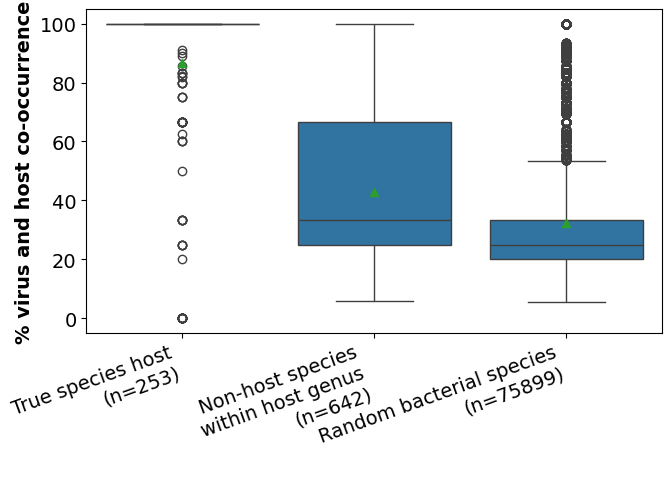

wrote pth_validation_pct_cooccur.png {'Random bacterial species': 75899, 'Non-host species within host genus': 642, 'True species host': 253}


/tmp/ipykernel_64307/1906292349.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


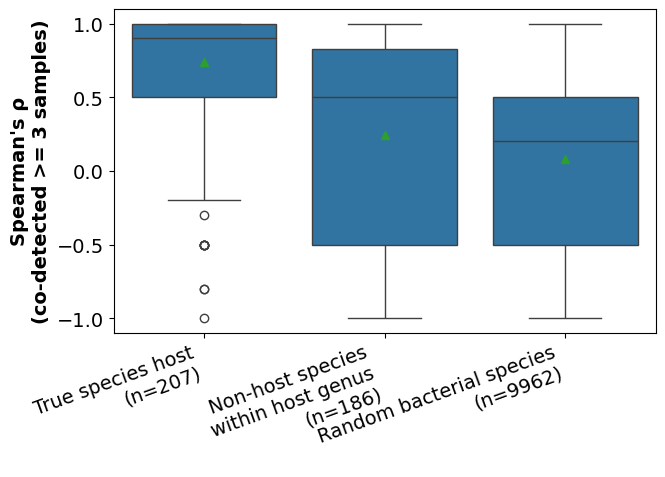

wrote pth_validation_spearman.png {'Random bacterial species': 9962, 'True species host': 207, 'Non-host species within host genus': 186}


/tmp/ipykernel_64307/1906292349.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


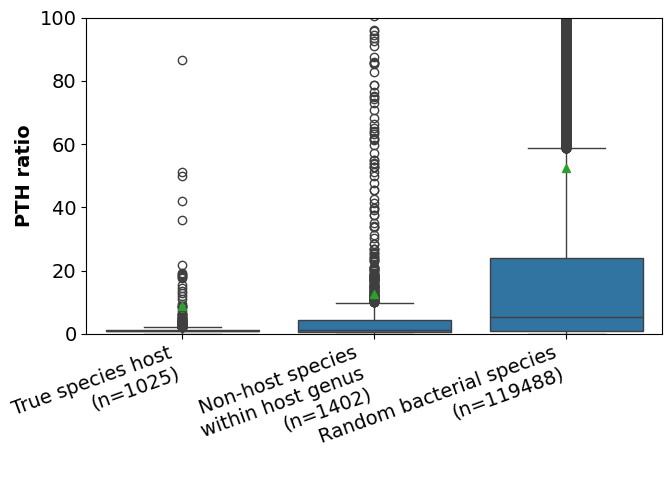

wrote pth_validation_raw_pth.png {'Random bacterial species': 119488, 'Non-host species within host genus': 1402, 'True species host': 1025}


/tmp/ipykernel_64307/1906292349.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


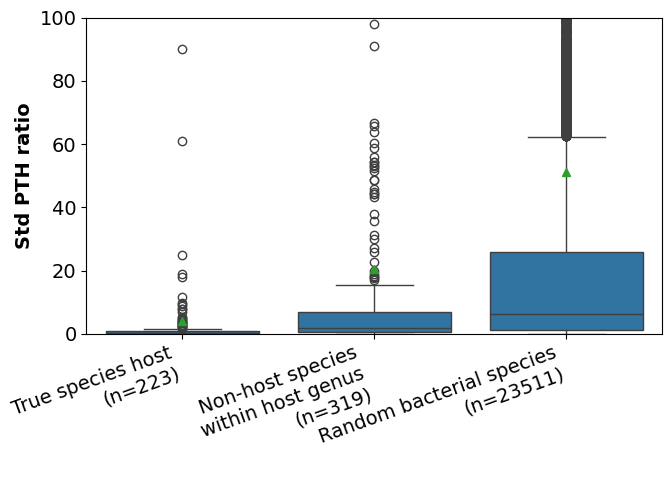

wrote pth_validation_std_pth.png {'Random bacterial species': 23511, 'Non-host species within host genus': 319, 'True species host': 223}
shape: (3, 2)
┌─────────────────────────────────┬───────┐
│ type                            ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Non-host species within host g… ┆ 642   │
│ True species host               ┆ 253   │
│ Random bacterial species        ┆ 75899 │
└─────────────────────────────────┴───────┘


In [6]:
plot_df = (
    final_plot_df
    .with_columns([
        (pl.col('p_value') + 1e-15).log10().mul(-1).alias('neg_log_p'),
    ])
    .to_pandas()
)

type_order = [
    'True species host',
    'Non-host species within host genus',
    'Random bacterial species',
]
type_display = {
    'True species host': 'True species host',
    'Non-host species within host genus': 'Non-host species\nwithin host genus',
    'Random bacterial species': 'Random bacterial species',
}
plot_df['type'] = pd.Categorical(plot_df['type'], categories=type_order, ordered=True)

raw_pth_pd = raw_pth_plot_df.to_pandas()
raw_pth_pd['type'] = pd.Categorical(raw_pth_pd['type'], categories=type_order, ordered=True)

panel_specs = [
    {
        'y': 'pct_cooccur',
        'data': plot_df,
        'ylabel': '% virus and host co-occurrence',
        'title': 'Percent co-occurrence',
        'out': 'pth_validation_pct_cooccur.png',
    },
    {
        'y': 'spearman_rho',
        'data': plot_df,
        'ylabel': "Spearman's ρ\n(co-detected >= 3 samples)",
        'title': 'Spearman correlation',
        'out': 'pth_validation_spearman.png',
    },
    {
        'y': 'sample_pth',
        'data': raw_pth_pd,
        'ylabel': 'PTH ratio',
        'title': 'Raw PTH',
        'out': 'pth_validation_raw_pth.png',
    },
    {
        'y': 'std_pth',
        'data': plot_df,
        'ylabel': 'Std PTH ratio',
        'title': 'PTH std',
        'out': 'pth_validation_std_pth.png',
    },
]

for spec in panel_specs:
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_data = spec['data'].dropna(subset=[spec['y']])
    counts = plot_data['type'].value_counts()
    tick_labels = [f'{type_display[t]}\n(n={int(counts.get(t, 0))})' for t in type_order]

    sns.boxplot(
        data=plot_data,
        x='type',
        y=spec['y'],
        order=type_order,
        showfliers=True,
        showmeans=True,
        ax=ax,
    )
    ax.set_xlabel('')
    ax.set_ylabel(spec['ylabel'], fontweight='bold', fontsize=14)
    if spec['y'] in ['sample_pth', 'std_pth']:
        ax.set_ylim(0, 100)
    # ax.set_title(spec['title'])
    ax.set_xticklabels(tick_labels)
    ax.tick_params(axis='x', labelrotation=20)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    fig.tight_layout()
    fig.savefig(spec['out'], dpi=200, bbox_inches='tight')
    plt.show()
    print('wrote', spec['out'], dict(counts))

print(final_plot_df['type'].value_counts())


In [7]:
# Median of median PTH and std PTH by type
med_by_type = (
    final_plot_df
    .group_by('type')
    .agg([
        pl.col('median_pth').median().alias('med_median_pth'),
        pl.col('std_pth').median().alias('med_std_pth'),
    ])
)
if 'type_order' in globals():
    med_by_type = med_by_type.with_columns(
        pl.col('type').cast(pl.Enum(type_order))
    ).sort('type')

print('Median of median PTH by type:')
print(med_by_type.select(['type', 'med_median_pth']))
print()
print('Median of std PTH by type:')
print(med_by_type.select(['type', 'med_std_pth']))


Median of median PTH by type:
shape: (3, 2)
┌─────────────────────────────────┬────────────────┐
│ type                            ┆ med_median_pth │
│ ---                             ┆ ---            │
│ enum                            ┆ f64            │
╞═════════════════════════════════╪════════════════╡
│ True species host               ┆ 0.986166       │
│ Non-host species within host g… ┆ 1.592961       │
│ Random bacterial species        ┆ 7.301034       │
└─────────────────────────────────┴────────────────┘

Median of std PTH by type:
shape: (3, 2)
┌─────────────────────────────────┬─────────────┐
│ type                            ┆ med_std_pth │
│ ---                             ┆ ---         │
│ enum                            ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ True species host               ┆ 0.399184    │
│ Non-host species within host g… ┆ 1.901834    │
│ Random bacterial species        ┆ 6.191544    │
└─────────────────────────────────┴──